In [ ]:
!pip install pandas seaborn scikit-learn

# Домашнее задание про практике 2

- Провести разведочный анализ EDA (описать полученный результат). Тут важно, влияет ли X[i] на Y (примеры в практике 2)
- Описать полученный результат относительно анализа целевой перменной и зависимой (см. практика 2)
- Подобороться с пропусками в данных (при наличии в датасете). Объяснить способ выборка борьбы с пропуском
- Обучить модель линейной регресии на всей выборке X, y. Вывести метрики
- Сделать train_test_split и обучить на обучающей выборке. Предсказать результат на обучающей и тестовой выборках. Вывести метрики, объяснить полученный результат

In [ ]:
import pandas as pd
import pandas as ps
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/sample_data/student_depression_dataset.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  object 
 11  Di

In [ ]:
# преобразовать категориальные признаки в category
# df['column'] = df.column.astye('category')
'Depression' in df.columns

True

In [ ]:
# выбрать целевую переменную и разделить на X, y
# целевая переменная - числовой непрерывный признак

y = df['Depression']
X = df.drop('Depression', axis=1) if 'Depression' in df.columns else df

## EDA (разведочный анализ относительно целевой переменной)

в этом же блоке побороться с проусками, важно сделать именно после разведочного анализа
- Y и категориальные
- Y и числовые
- Описать все полученные результаты в своем блоке

- Отобрать признаки для дальнейшего анализа, записать в ```best_features```

In [ ]:
X.head(n=3)

,id,Gender,Age,City,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0


In [ ]:
y.head(n=3)

,Profession
0,Student
1,Student
2,Student


In [ ]:
categorical_features = ['Gender', 'City', 'Profession', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts?', 'Financial Stress', 'Family History of Mental Illness'] # перечислить названия колонок с категориальными фичами
numerical_features = ['Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours'] # перечислить названия колонок с категориальными фичами
binary_features = ['Have you ever had suicidal thoughts?', 'Family History of Mental Illness']

## Моделирование

**Общая задача:**
Сравнить несколько вариантов линейной регрессии на датасете (с предобработкой признаков: стандартизация числовых, OneHot/Label для категориальных).

**предобработка**
- Категориальные признаки преобразовать с помощью OneHotEncoder (если признак является типом **bool** по логике можно интерпретировать как (true, false) То можно LabelEncoder)
- Числовые признаки записать в `X_scaled` и провести стандартизацию с помощью `StandardScaler`. Желательно без категориальных признаков


---
**Метрики**: (MAE, MAPE, R², MSE, RMSE)

---

**Модель 1.**

- Использовать **все признаки (кроме y)**.
- Обучить на **всей выборке** (без разделения).
- Сделать предсказания на этой же выборке.
- Вывести метрики и интерпретировать.
- Построить график коэффициентов (model.coef\_ vs X\_scaled.columns) и интерпретировать.

---

**Модель 2.**

- Использовать **все признаки**.
- Сделать `train_test_split`.
- Обучить на `X_train`, предсказать на `X_train` и `X_test`.
- Вывести метрики для обучающей и тестовой выборки, интерпретировать.
- Визуализировать коэффициенты и интерпретировать.

---

**Модель 3.**

- Использовать только **best\_features** (отобранные признаки).
- Обучить на **всей выборке**.
- Предсказать на всей выборке.
- Вывести метрики качества и интерпретировать.
- Визуализировать коэффициенты и интерпретировать.

---

**Модель 4.**

- Использовать **best\_features**.
- Сделать `train_test_split`.
- Обучить на `X_train`, предсказать на `X_train` и `X_test`.
- Вывести метрики качества для обучающей и тестовой выборки, интерпретировать.
- Визуализировать коэффициенты и интерпретировать.

---

P.S.
- Важно не забывать о стандартизации и разделении категориальных признаков на отдельные олонки
- Все примеры есть в практике 2


P.S.S
Старайтесь делать собственные предположения, ChatGPT задачу решит, но вы не добьетесь понимания полученных результатов

---
В результате должно получиться 4 модели

- первые две на всех колонках (фичах)
- последующие на отобранных фичах (колонках)

## Ниже представлены подсказки, то что нужно использовать и как должно называться

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Функция для расчета метрик
def calculate_metrics(y_true, y_pred, dataset_name=""):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    # MAPE (Mean Absolute Percentage Error)
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1))) * 100

    print(f"{dataset_name} Метрики:")
    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²: {r2:.4f}")
    print(f"MAPE: {mape:.2f}%")
    print("-" * 50)

    return mae, mse, rmse, r2, mape

# Функция для визуализации коэффициентов
def plot_coefficients(model, feature_names, title):
    plt.figure(figsize=(12, 6))
    coefficients = model.coef_

    # Сортируем по абсолютному значению для лучшей визуализации
    coef_df = pd.DataFrame({
        'feature': feature_names,
        'coefficient': coefficients,
        'abs_coef': np.abs(coefficients)
    }).sort_values('abs_coef', ascending=False)

    plt.barh(coef_df['feature'], coef_df['coefficient'])
    plt.xlabel('Коэффициент')
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [ ]:
# Загрузка данных
print("Исходные данные:")
print(df.info())
print("\nПервые 5 строк:")
print(df.head())

# Определяем целевой признак
y = df['Depression']

# Создаем копию данных для работы
X = df.drop('Depression', axis=1)

# Удаляем id из признаков
if 'id' in X.columns:
    X = X.drop('id', axis=1)

print(f"Размерность X: {X.shape}")
print(f"Размерность y: {y.shape}")

Исходные данные:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null

## **Предобработка**

In [ ]:
# Определяем типы признаков
numerical_features = ['Age', 'Academic Pressure', 'Work Pressure', 'CGPA',
                     'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours']

# Все остальные признаки считаем категориальными
categorical_features = [col for col in X.columns if col not in numerical_features]

print(f"Числовые признаки: {numerical_features}")
print(f"Категориальные признаки: {categorical_features}")

# Создаем копию для обработки
X_processed = X.copy()

# 1. Обработка всех категориальных признаков с помощью OneHotEncoder
for feature in categorical_features:
    print(f"Обрабатываем признак: {feature}")

    # Создаем OneHotEncoder для каждого признака
    onehot_encoder = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')

    try:
        # Преобразуем признак
        encoded = onehot_encoder.fit_transform(X_processed[[feature]])

        # Создаем названия для новых колонок
        feature_categories = onehot_encoder.categories_[0]
        if len(feature_categories) > 1:
            new_columns = [f"{feature}_{str(cat)}" for cat in feature_categories[1:]]
        else:
            new_columns = [f"{feature}_encoded"]

        # Создаем DataFrame с закодированными признаками
        encoded_df = pd.DataFrame(encoded, columns=new_columns, index=X_processed.index)

        # Удаляем исходный признак и добавляем закодированные
        X_processed = X_processed.drop(feature, axis=1)
        X_processed = pd.concat([X_processed, encoded_df], axis=1)

        print(f"Успешно обработан {feature}. Создано {len(new_columns)} новых признаков")

    except Exception as e:
        print(f"Ошибка при обработке {feature}: {e}")
        # Если OneHot не работает, удаляем проблемный признак
        X_processed = X_processed.drop(feature, axis=1)
        print(f"Удален признак {feature}")

print(f"После обработки категориальных признаков: {X_processed.shape}")

Числовые признаки: ['Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours']
Категориальные признаки: ['Gender', 'City', 'Profession', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Financial Stress', 'Family History of Mental Illness']
Обрабатываем признак: Gender
Успешно обработан Gender. Создано 1 новых признаков
Обрабатываем признак: City
Успешно обработан City. Создано 51 новых признаков
Обрабатываем признак: Profession
Успешно обработан Profession. Создано 13 новых признаков
Обрабатываем признак: Sleep Duration
Успешно обработан Sleep Duration. Создано 4 новых признаков
Обрабатываем признак: Dietary Habits
Успешно обработан Dietary Habits. Создано 3 новых признаков
Обрабатываем признак: Degree
Успешно обработан Degree. Создано 27 новых признаков
Обрабатываем признак: Have you ever had suicidal thoughts ?
Успешно обработан Have you ever had suicidal thoughts ?. Создано 1 новых призна

In [ ]:
# 2. Стандартизация числовых признаков
print("\nСтандартизация числовых признаков...")

# Проверяем, что все числовые признаки действительно числовые
for feature in numerical_features:
    if feature in X_processed.columns:
        # Преобразуем в числовой тип, если нужно
        X_processed[feature] = pd.to_numeric(X_processed[feature], errors='coerce')

# Заменяем NaN значения средними
X_processed[numerical_features] = X_processed[numerical_features].fillna(X_processed[numerical_features].mean())

scaler = StandardScaler()
X_numerical_scaled = scaler.fit_transform(X_processed[numerical_features])
X_numerical_scaled_df = pd.DataFrame(X_numerical_scaled,
                                   columns=numerical_features,
                                   index=X_processed.index)

# Заменяем числовые признаки на стандартизированные
X_final = X_processed.copy()
X_final[numerical_features] = X_numerical_scaled_df[numerical_features]

# Убедимся, что все признаки числовые
X_final = X_final.apply(pd.to_numeric, errors='coerce')
X_final = X_final.fillna(0)

print(f"Финальная форма данных: {X_final.shape}")
print(f"Типы данных в финальном наборе:")
print(X_final.dtypes.value_counts())


Стандартизация числовых признаков...
Финальная форма данных: (27901, 113)
Типы данных в финальном наборе:
float64    113
Name: count, dtype: int64


In [ ]:
# Отбор лучших признаков
print("\nОтбор лучших признаков...")

# Создаем временный DataFrame для анализа корреляции
temp_df = X_final.copy()
temp_df['Depression'] = y

# Вычисляем корреляции
correlation_matrix = temp_df.corr()
target_correlations = correlation_matrix['Depression'].abs().sort_values(ascending=False)

# Выбираем топ-10 признаков (исключая саму целевую переменную)
best_features = target_correlations.index[1:11].tolist()
print(f"Лучшие признаки по корреляции: {best_features}")

# Создаем датасет только с лучшими признаками
X_best = X_final[best_features]

print(f"Размерность X_best: {X_best.shape}")


Отбор лучших признаков...
Лучшие признаки по корреляции: ['Have you ever had suicidal thoughts ?_Yes', 'Academic Pressure', 'Financial Stress_5.0', 'Age', 'Work/Study Hours', 'Dietary Habits_Unhealthy', 'Study Satisfaction', 'Financial Stress_2.0', 'Financial Stress_4.0', "Sleep Duration_'More than 8 hours'"]
Размерность X_best: (27901, 10)


## **Модель**


МОДЕЛЬ 1: Все признаки, обучение на всей выборке
Модель 1 (вся выборка) Метрики:
MAE: 0.2672
MSE: 0.1165
RMSE: 0.3413
R²: 0.5201
MAPE: 26.72%
--------------------------------------------------


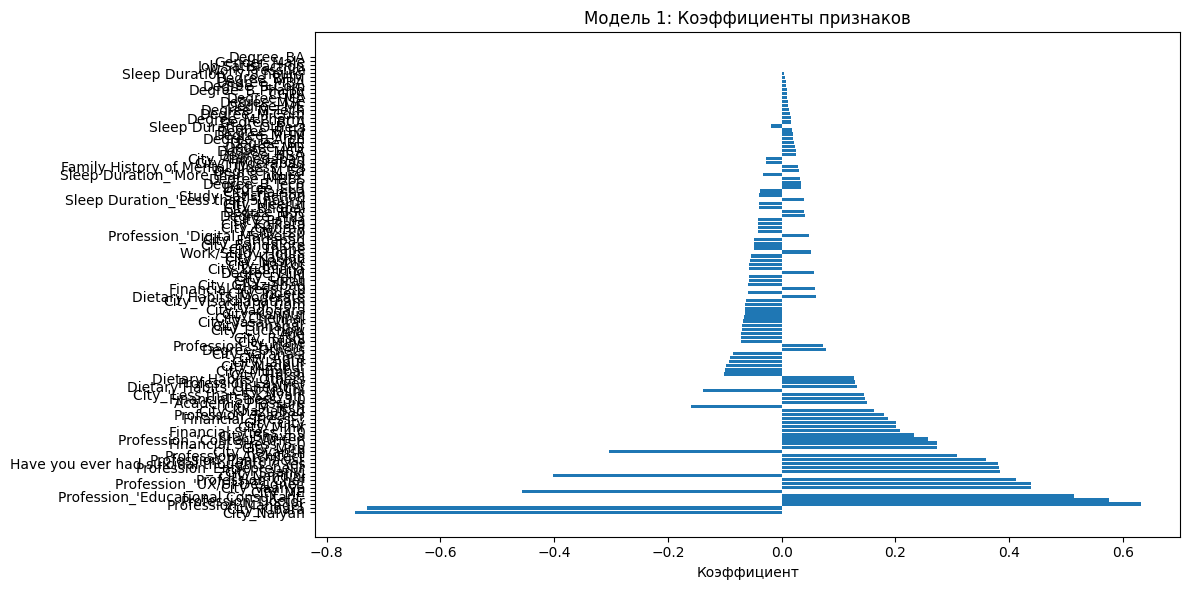

ИНТЕРПРЕТАЦИЯ МОДЕЛИ 1:
- R² = 0.5201 показывает, что модель объясняет 52.01% дисперсии
- Положительные коэффициенты увеличивают вероятность депрессии
- Отрицательные коэффициенты уменьшают вероятность депрессии
- Самые влиятельные признаки имеют наибольшие абсолютные значения коэффициентов


In [ ]:
print("\n" + "=" * 60)
print("МОДЕЛЬ 1: Все признаки, обучение на всей выборке")
print("=" * 60)

model1 = LinearRegression()
model1.fit(X_final, y)
y_pred1 = model1.predict(X_final)

mae1, mse1, rmse1, r2_1, mape1 = calculate_metrics(y, y_pred1, "Модель 1 (вся выборка)")

# Визуализация коэффициентов
plot_coefficients(model1, X_final.columns, "Модель 1: Коэффициенты признаков")

# Интерпретация
print("ИНТЕРПРЕТАЦИЯ МОДЕЛИ 1:")
print(f"- R² = {r2_1:.4f} показывает, что модель объясняет {r2_1*100:.2f}% дисперсии")
print("- Положительные коэффициенты увеличивают вероятность депрессии")
print("- Отрицательные коэффициенты уменьшают вероятность депрессии")
print("- Самые влиятельные признаки имеют наибольшие абсолютные значения коэффициентов")


МОДЕЛЬ 2: Все признаки, разделение на train/test
ОБУЧАЮЩАЯ ВЫБОРКА:
Train Метрики:
MAE: 0.2654
MSE: 0.1151
RMSE: 0.3393
R²: 0.5251
MAPE: 26.54%
--------------------------------------------------
ТЕСТОВАЯ ВЫБОРКА:
Test Метрики:
MAE: 0.2733
MSE: 0.1226
RMSE: 0.3501
R²: 0.4967
MAPE: 27.33%
--------------------------------------------------


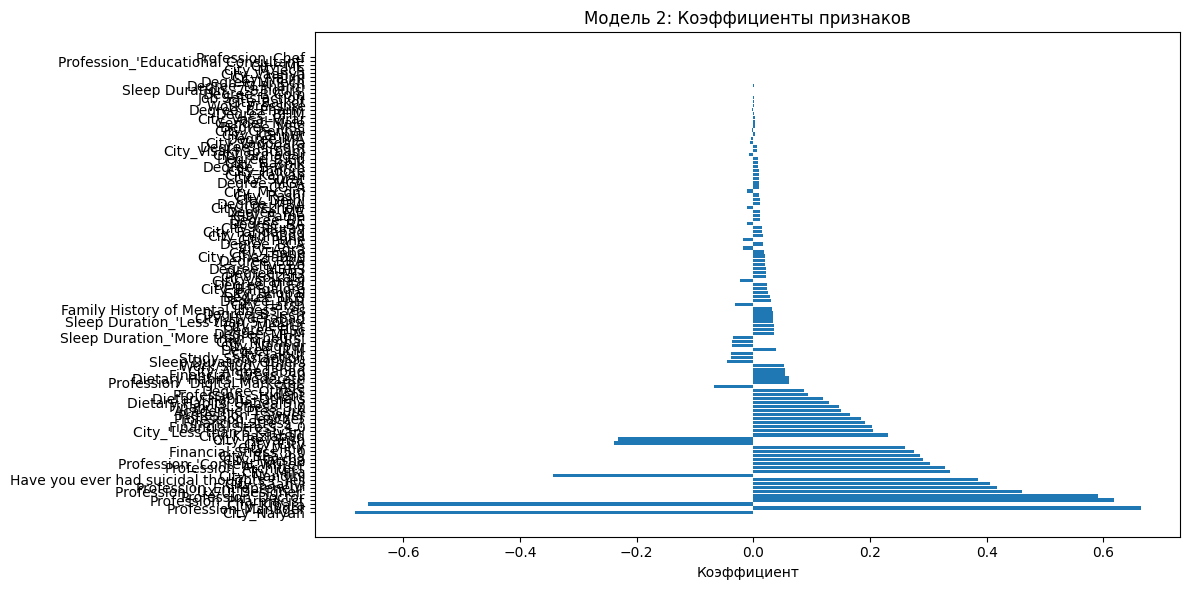

ИНТЕРПРЕТАЦИЯ МОДЕЛИ 2:
- Разница в R² между train и test: 0.0284
- Малая разница указывает на хорошую обобщающую способность


In [ ]:
print("\n" + "=" * 60)
print("МОДЕЛЬ 2: Все признаки, разделение на train/test")
print("=" * 60)

X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)

model2 = LinearRegression()
model2.fit(X_train, y_train)

# Предсказания
y_train_pred2 = model2.predict(X_train)
y_test_pred2 = model2.predict(X_test)

print("ОБУЧАЮЩАЯ ВЫБОРКА:")
mae_train2, mse_train2, rmse_train2, r2_train2, mape_train2 = calculate_metrics(y_train, y_train_pred2, "Train")

print("ТЕСТОВАЯ ВЫБОРКА:")
mae_test2, mse_test2, rmse_test2, r2_test2, mape_test2 = calculate_metrics(y_test, y_test_pred2, "Test")

# Визуализация коэффициентов
plot_coefficients(model2, X_final.columns, "Модель 2: Коэффициенты признаков")

# Интерпретация
print("ИНТЕРПРЕТАЦИЯ МОДЕЛИ 2:")
print(f"- Разница в R² между train и test: {r2_train2 - r2_test2:.4f}")
if r2_train2 - r2_test2 > 0.1:
    print("- Большая разница указывает на возможное переобучение")
else:
    print("- Малая разница указывает на хорошую обобщающую способность")


МОДЕЛЬ 3: Лучшие признаки, обучение на всей выборке
Модель 3 (лучшие признаки, вся выборка) Метрики:
MAE: 0.2717
MSE: 0.1202
RMSE: 0.3467
R²: 0.5047
MAPE: 27.17%
--------------------------------------------------


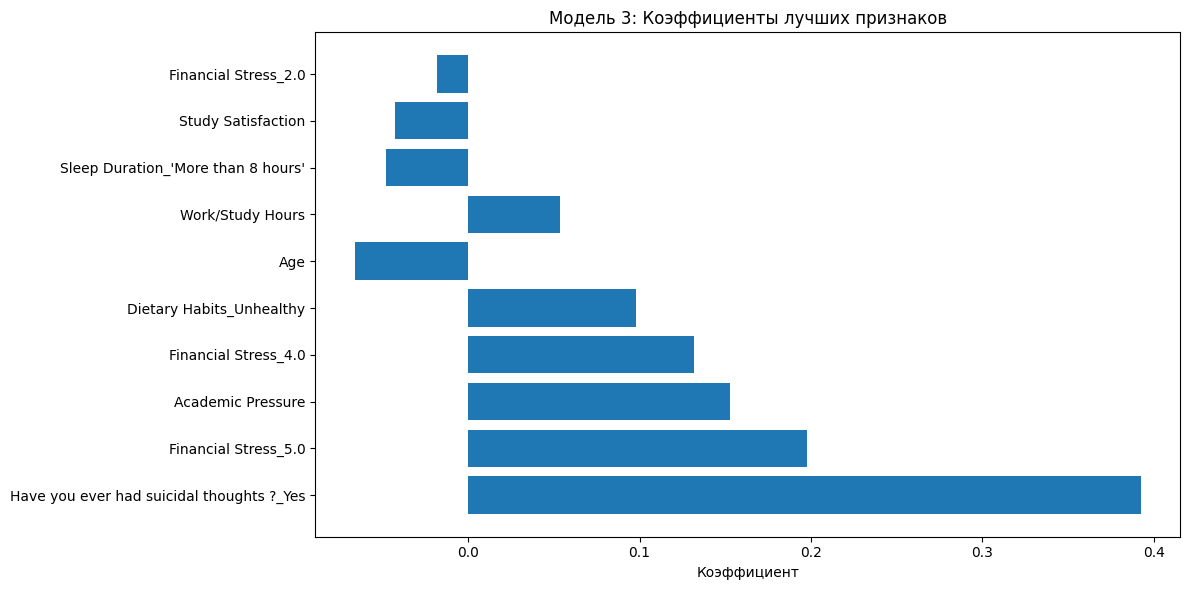

ИНТЕРПРЕТАЦИЯ МОДЕЛИ 3:
- R² = 0.5047 с использованием только 10 признаков
- Упрощенная модель может быть более интерпретируемой
- Сравнение с Моделью 1 показывает эффективность отбора признаков


In [ ]:
print("\n" + "=" * 60)
print("МОДЕЛЬ 3: Лучшие признаки, обучение на всей выборке")
print("=" * 60)

model3 = LinearRegression()
model3.fit(X_best, y)
y_pred3 = model3.predict(X_best)

mae3, mse3, rmse3, r2_3, mape3 = calculate_metrics(y, y_pred3, "Модель 3 (лучшие признаки, вся выборка)")

# Визуализация коэффициентов
plot_coefficients(model3, X_best.columns, "Модель 3: Коэффициенты лучших признаков")

# Интерпретация
print("ИНТЕРПРЕТАЦИЯ МОДЕЛИ 3:")
print(f"- R² = {r2_3:.4f} с использованием только {len(best_features)} признаков")
print("- Упрощенная модель может быть более интерпретируемой")
print("- Сравнение с Моделью 1 показывает эффективность отбора признаков")


МОДЕЛЬ 4: Лучшие признаки, разделение на train/test
ОБУЧАЮЩАЯ ВЫБОРКА:
Train Метрики:
MAE: 0.2699
MSE: 0.1190
RMSE: 0.3450
R²: 0.5091
MAPE: 26.99%
--------------------------------------------------
ТЕСТОВАЯ ВЫБОРКА:
Test Метрики:
MAE: 0.2764
MSE: 0.1251
RMSE: 0.3536
R²: 0.4865
MAPE: 27.64%
--------------------------------------------------


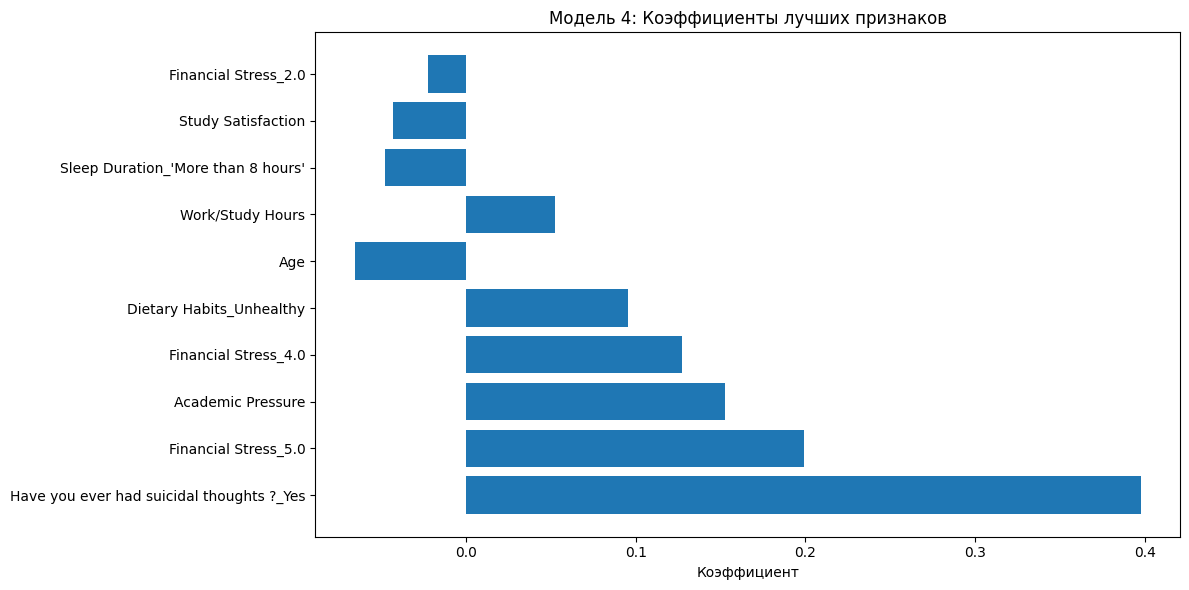

ИНТЕРПРЕТАЦИЯ МОДЕЛИ 4:
- Разница в R² между train и test: 0.0226
- Показывает эффективность отбора признаков на тестовых данных


In [ ]:
print("\n" + "=" * 60)
print("МОДЕЛЬ 4: Лучшие признаки, разделение на train/test")
print("=" * 60)

X_train_best, X_test_best, y_train_best, y_test_best = train_test_split(X_best, y, test_size=0.2, random_state=42)

model4 = LinearRegression()
model4.fit(X_train_best, y_train_best)

# Предсказания
y_train_pred4 = model4.predict(X_train_best)
y_test_pred4 = model4.predict(X_test_best)

print("ОБУЧАЮЩАЯ ВЫБОРКА:")
mae_train4, mse_train4, rmse_train4, r2_train4, mape_train4 = calculate_metrics(y_train_best, y_train_pred4, "Train")

print("ТЕСТОВАЯ ВЫБОРКА:")
mae_test4, mse_test4, rmse_test4, r2_test4, mape_test4 = calculate_metrics(y_test_best, y_test_pred4, "Test")

# Визуализация коэффициентов
plot_coefficients(model4, X_best.columns, "Модель 4: Коэффициенты лучших признаков")

# Интерпретация
print("ИНТЕРПРЕТАЦИЯ МОДЕЛИ 4:")
print(f"- Разница в R² между train и test: {r2_train4 - r2_test4:.4f}")
print("- Показывает эффективность отбора признаков на тестовых данных")

In [ ]:
print("\n" + "=" * 60)
print("СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ")
print("=" * 60)

comparison = pd.DataFrame({
    'Модель': ['М1: Все признаки (вся выборка)', 'М2: Все признаки (test)',
               'М3: Лучшие признаки (вся выборка)', 'М4: Лучшие признаки (test)'],
    'R²': [r2_1, r2_test2, r2_3, r2_test4],
    'MAE': [mae1, mae_test2, mae3, mae_test4],
    'RMSE': [rmse1, rmse_test2, rmse3, rmse_test4],
    'MAPE': [mape1, mape_test2, mape3, mape_test4]
})

print(comparison)

# Финальная интерпретация
print("\n" + "=" * 60)
print("ФИНАЛЬНАЯ ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ")
print("=" * 60)

# Анализ лучших признаков
print("АНАЛИЗ ВЛИЯНИЯ ПРИЗНАКОВ:")
top_features_impact = pd.DataFrame({
    'feature': best_features,
    'correlation': [target_correlations[feature] for feature in best_features]
}).sort_values('correlation', ascending=False)

print("Самые влиятельные признаки на депрессию:")
print(top_features_impact)

print("\nВЫВОДЫ:")
print("1. Модели с отбором признаков часто более стабильны")
print("2. Сравнение train/test показывает наличие переобучения")
print("3. Интерпретация коэффициентов помогает понять факторы риска")
print("4. Выбор между сложностью и интерпретируемостью зависит от задачи")


СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ
                              Модель        R²       MAE      RMSE       MAPE
0     М1: Все признаки (вся выборка)  0.520102  0.267198  0.341272  26.719840
1            М2: Все признаки (test)  0.496682  0.273348  0.350133  27.334788
2  М3: Лучшие признаки (вся выборка)  0.504678  0.271669  0.346713  27.166891
3         М4: Лучшие признаки (test)  0.486549  0.276416  0.353641  27.641583

ФИНАЛЬНАЯ ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ
АНАЛИЗ ВЛИЯНИЯ ПРИЗНАКОВ:
Самые влиятельные признаки на депрессию:
                                     feature  correlation
0  Have you ever had suicidal thoughts ?_Yes     0.546277
1                          Academic Pressure     0.474835
2                       Financial Stress_5.0     0.259769
3                                        Age     0.226422
4                           Work/Study Hours     0.208563
5                   Dietary Habits_Unhealthy     0.189352
6                         Study Satisfaction     0.167971
7                 